# plot145


# LSST

Removed no burn in
Saved: /home/geng/Codes/lensing_cosmo/jax01/output_lsst_sim/getdist_peak_lsst145_wcdm.png


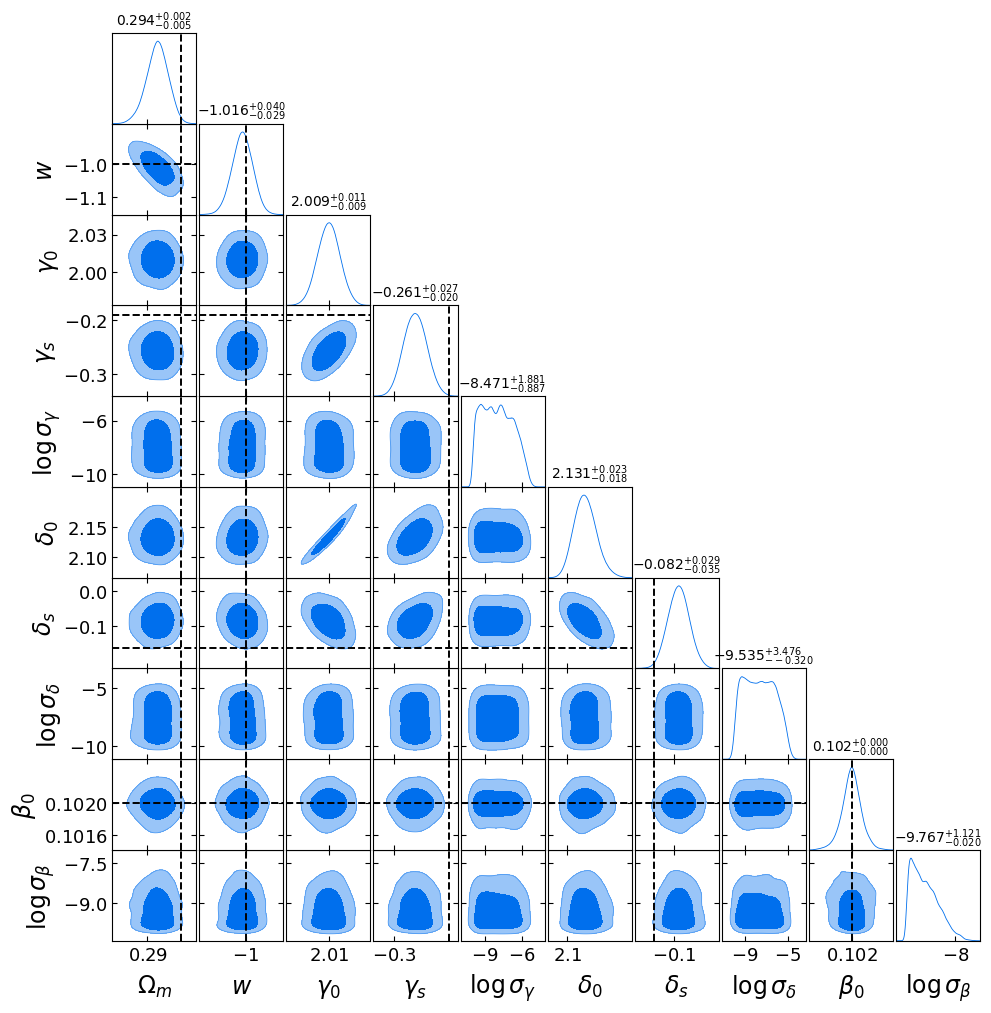

In [1]:
import os
import numpy as np
from getdist import MCSamples, plots as gdplots

BASE_OUT = "/home/geng/Codes/lensing_cosmo/jax01/output_lsst_sim"
full_labels = {
    "wcdm": "lsst145_wcdm",
    # "w0wa": "lsst145_w0wa",
}

tail_keys = [
    "gamma0", "gamma_s", "log_sig_g",
    "delta0", "delta_s", "log_sig_d",
    "beta0", "log_sig_b",
]

ref_markers = {
    "wcdm": {
        "Om": 0.3, "w": -1.0,
        "gamma0": 2.054, "gamma_s": -0.19,
        "delta0": 2.26, "delta_s": -0.16,
        "beta0": 0.102,
    },
    "w0wa": {
        "Om": 0.3, "w0": -0.75, "wa": -0.86,
        "gamma0": 2.054, "gamma_s": -0.19,
        "delta0": 2.26, "delta_s": -0.16,
        "beta0": 0.102,
    },
}

def head_keys_for(model):
    if model == "wcdm":
        return ["Om", "w"]
    if model == "w0wa":
        return ["Om", "w0", "wa"]
    raise ValueError(f"unknown model: {model}")

def load_samples(npz_path, keys):
    data = np.load(npz_path)
    missing = [k for k in keys if k not in data.files]
    if missing:
        raise KeyError(f"npz missing keys: {missing}\navailable: {list(data.files)}")
    return np.vstack([data[k] for k in keys]).T

def peak_q16_q84(x, bins=200):
    hist, edges = np.histogram(x, bins=bins, density=True)
    i = int(np.argmax(hist))
    peak = 0.5 * (edges[i] + edges[i+1])
    q16, q84 = np.quantile(x, [0.16, 0.84])
    return float(peak), float(q16), float(q84)

name_map = {
    "Om": "Om", "w": "w", "w0": "w0", "wa": "wa",
    "gamma0": "gamma0", "gamma_s": "gamma_s", "log_sig_g": "log_sig_g",
    "delta0": "delta0", "delta_s": "delta_s", "log_sig_d": "log_sig_d",
    "beta0": "beta0", "log_sig_b": "log_sig_b",
}
label_map = {
    "Om": r"\Omega_m", "w": r"w", "w0": r"w_0", "wa": r"w_a",
    "gamma0": r"\gamma_0", "gamma_s": r"\gamma_s", "log_sig_g": r"\log\sigma_\gamma",
    "delta0": r"\delta_0", "delta_s": r"\delta_s", "log_sig_d": r"\log\sigma_\delta",
    "beta0": r"\beta_0", "log_sig_b": r"\log\sigma_\beta",
}

for model, label in full_labels.items():
    npz_path = os.path.join(BASE_OUT, f"posterior_minimal_chunks_{label}.npz")
    keys = head_keys_for(model) + tail_keys
    samples = load_samples(npz_path, keys)

    burn = int(0.4 * samples.shape[0])
    samples2 = samples[burn:]

    names = [name_map[k] for k in keys]
    labels = [label_map.get(k, k) for k in keys]

    mc = MCSamples(samples=samples2, names=names, labels=labels, label=label)
    g = gdplots.get_subplot_plotter(width_inch=10)
    g.settings.axes_labelsize = 22
    g.settings.axes_fontsize = 18
    g.triangle_plot(
        [mc],
        filled=True,
        title_limit=0,
        markers=ref_markers[model],
        marker_args={"lw": 1.4, "ls": "--", "color": "k"},
    )

    for i, k in enumerate(keys):
        peak, q16, q84 = peak_q16_q84(samples2[:, i])
        dminus = peak - q16
        dplus = q84 - peak
        ax = g.subplots[i, i]
        ax.set_title(rf"${peak:.3f}_{{-{dminus:.3f}}}^{{+{dplus:.3f}}}$", fontsize=10)

    out_path = os.path.join(BASE_OUT, f"getdist_peak_{label}.png")
    g.export(out_path)
    print("Saved:", out_path)


Removed no burn in
Saved: /home/geng/Codes/lensing_cosmo/jax01/output_lsst_sim/getdist_peak_lsst145_wcdm_ann0.1.png
Removed no burn in
Saved: /home/geng/Codes/lensing_cosmo/jax01/output_lsst_sim/getdist_peak_lsst145_w0wa_ann0.1.png


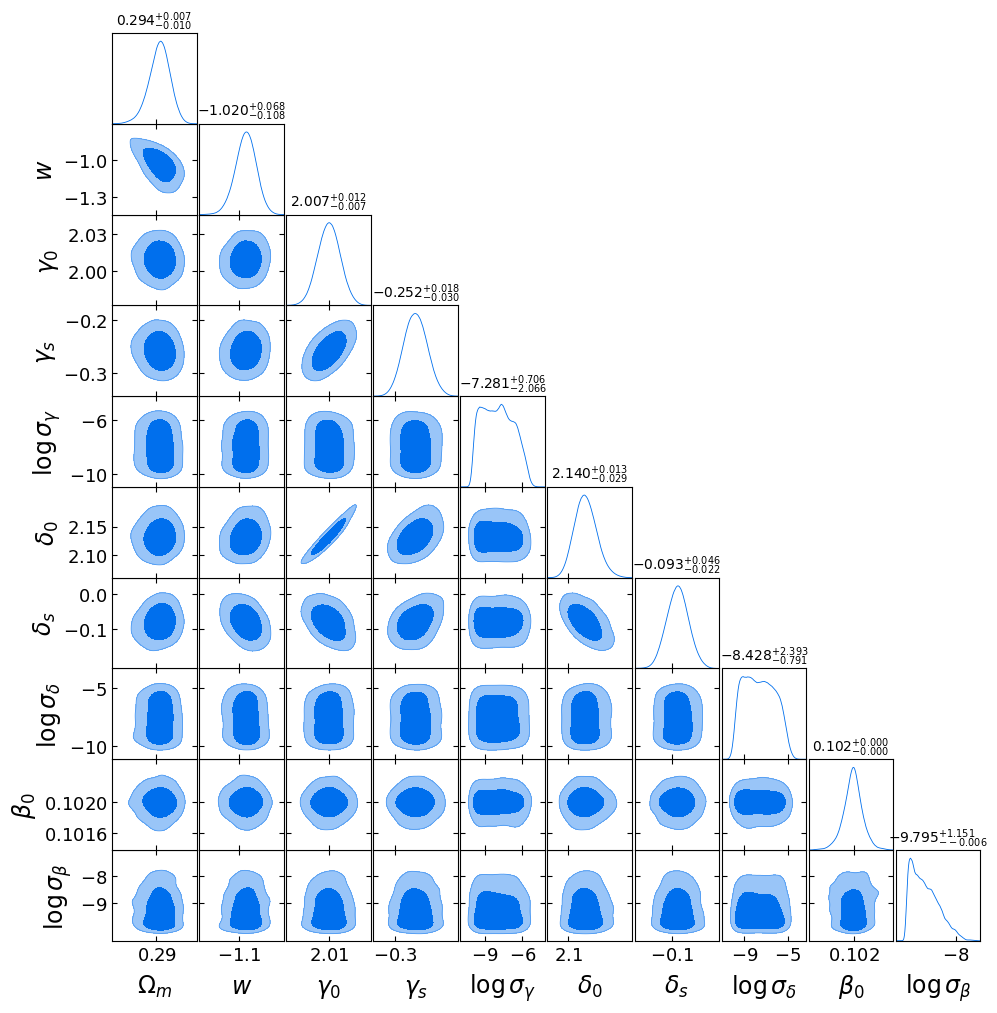

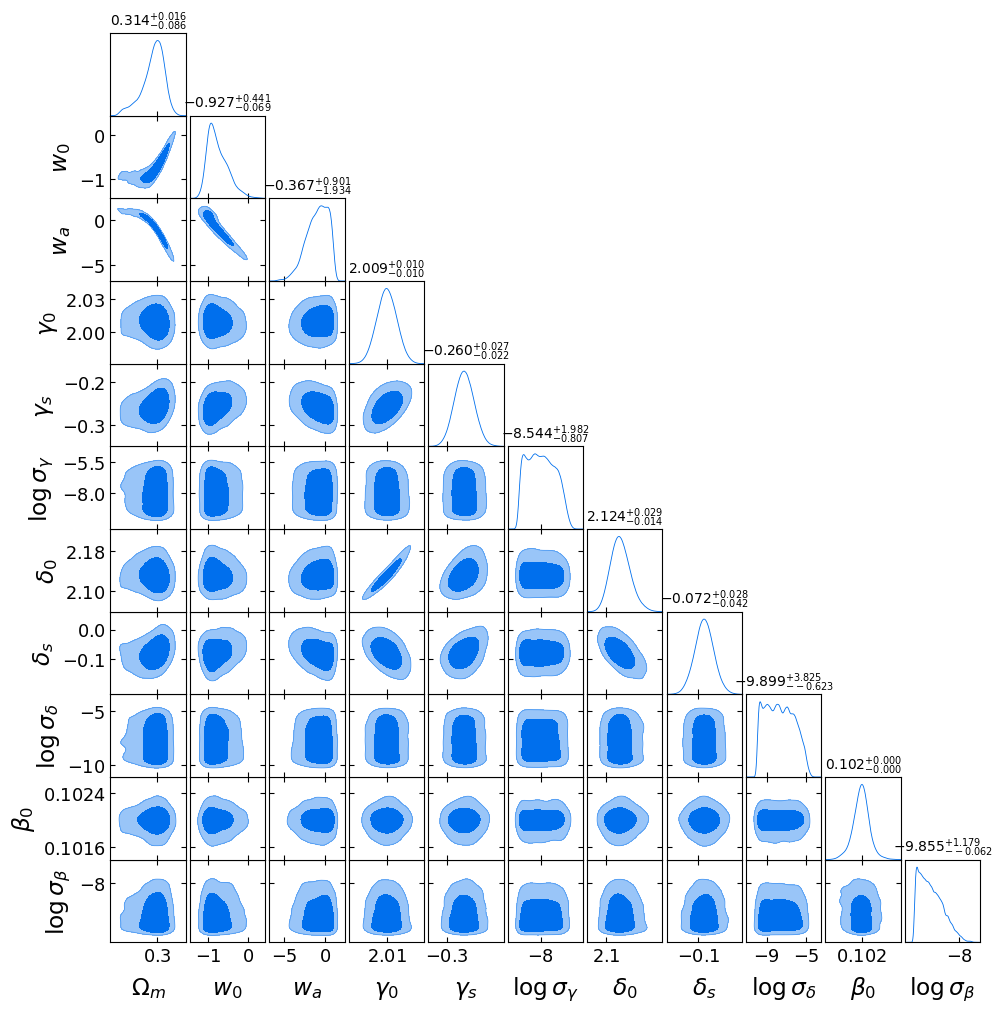

In [3]:
import os
import numpy as np
from getdist import MCSamples, plots as gdplots

BASE_OUT = "/home/geng/Codes/lensing_cosmo/jax01/output_lsst_sim"
full_labels = {
    "wcdm": "lsst145_wcdm_ann0.1",
    "w0wa": "lsst145_w0wa_ann0.1",
}

tail_keys = [
    "gamma0", "gamma_s", "log_sig_g",
    "delta0", "delta_s", "log_sig_d",
    "beta0", "log_sig_b",
]

ref_markers = {
    "wcdm": {
        "Om": 0.3, "w": -1.0,
        "gamma0": 2.054, "gamma_s": -0.19,
        "delta0": 2.26, "delta_s": -0.16,
        "beta0": 0.102,
    },
    "w0wa": {
        "Om": 0.3, "w0": -0.75, "wa": -0.86,
        "gamma0": 2.054, "gamma_s": -0.19,
        "delta0": 2.26, "delta_s": -0.16,
        "beta0": 0.102,
    },
}

def head_keys_for(model):
    if model == "wcdm":
        return ["Om", "w"]
    if model == "w0wa":
        return ["Om", "w0", "wa"]
    raise ValueError(f"unknown model: {model}")

def load_samples(npz_path, keys):
    data = np.load(npz_path)
    missing = [k for k in keys if k not in data.files]
    if missing:
        raise KeyError(f"npz missing keys: {missing}\navailable: {list(data.files)}")
    return np.vstack([data[k] for k in keys]).T

def peak_q16_q84(x, bins=200):
    hist, edges = np.histogram(x, bins=bins, density=True)
    i = int(np.argmax(hist))
    peak = 0.5 * (edges[i] + edges[i+1])
    q16, q84 = np.quantile(x, [0.16, 0.84])
    return float(peak), float(q16), float(q84)

name_map = {
    "Om": "Om", "w": "w", "w0": "w0", "wa": "wa",
    "gamma0": "gamma0", "gamma_s": "gamma_s", "log_sig_g": "log_sig_g",
    "delta0": "delta0", "delta_s": "delta_s", "log_sig_d": "log_sig_d",
    "beta0": "beta0", "log_sig_b": "log_sig_b",
}
label_map = {
    "Om": r"\Omega_m", "w": r"w", "w0": r"w_0", "wa": r"w_a",
    "gamma0": r"\gamma_0", "gamma_s": r"\gamma_s", "log_sig_g": r"\log\sigma_\gamma",
    "delta0": r"\delta_0", "delta_s": r"\delta_s", "log_sig_d": r"\log\sigma_\delta",
    "beta0": r"\beta_0", "log_sig_b": r"\log\sigma_\beta",
}

for model, label in full_labels.items():
    npz_path = os.path.join(BASE_OUT, f"posterior_minimal_chunks_{label}.npz")
    keys = head_keys_for(model) + tail_keys
    samples = load_samples(npz_path, keys)

    burn = int(0.4 * samples.shape[0])
    samples2 = samples[burn:]

    names = [name_map[k] for k in keys]
    labels = [label_map.get(k, k) for k in keys]

    mc = MCSamples(samples=samples2, names=names, labels=labels, label=label)
    g = gdplots.get_subplot_plotter(width_inch=10)
    g.settings.axes_labelsize = 22
    g.settings.axes_fontsize = 18
    g.triangle_plot(
        [mc],
        filled=True,
        title_limit=0,
        # markers=ref_markers[model],
        # marker_args={"lw": 1.4, "ls": "--", "color": "k"},
    )

    for i, k in enumerate(keys):
        peak, q16, q84 = peak_q16_q84(samples2[:, i])
        dminus = peak - q16
        dplus = q84 - peak
        ax = g.subplots[i, i]
        ax.set_title(rf"${peak:.3f}_{{-{dminus:.3f}}}^{{+{dplus:.3f}}}$", fontsize=10)

    out_path = os.path.join(BASE_OUT, f"getdist_peak_{label}.png")
    g.export(out_path)
    print("Saved:", out_path)


Removed no burn in
Saved: /home/geng/Codes/lensing_cosmo/jax01/output_lsst_sim/getdist_peak_lsst146_wcdm_ann080.png
Removed no burn in
Saved: /home/geng/Codes/lensing_cosmo/jax01/output_lsst_sim/getdist_peak_lsst146_w0wa_ann080.png


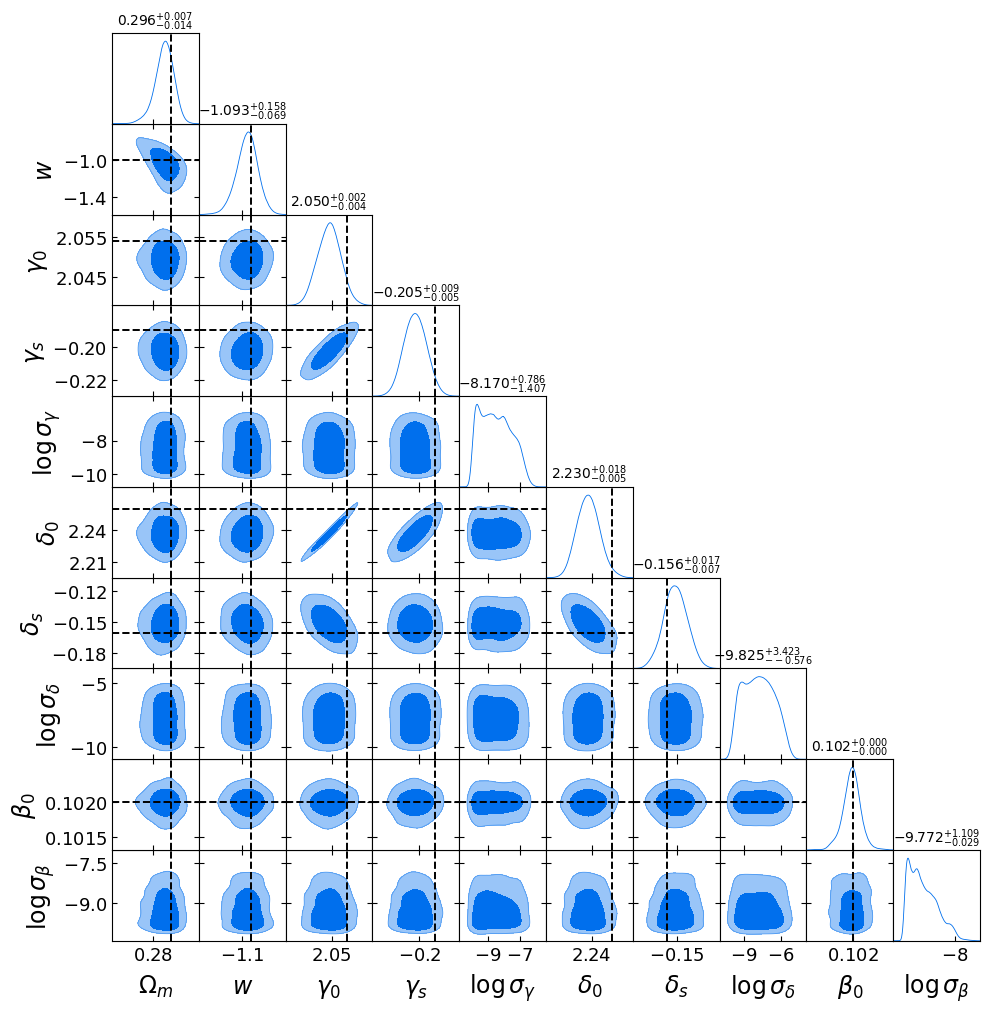

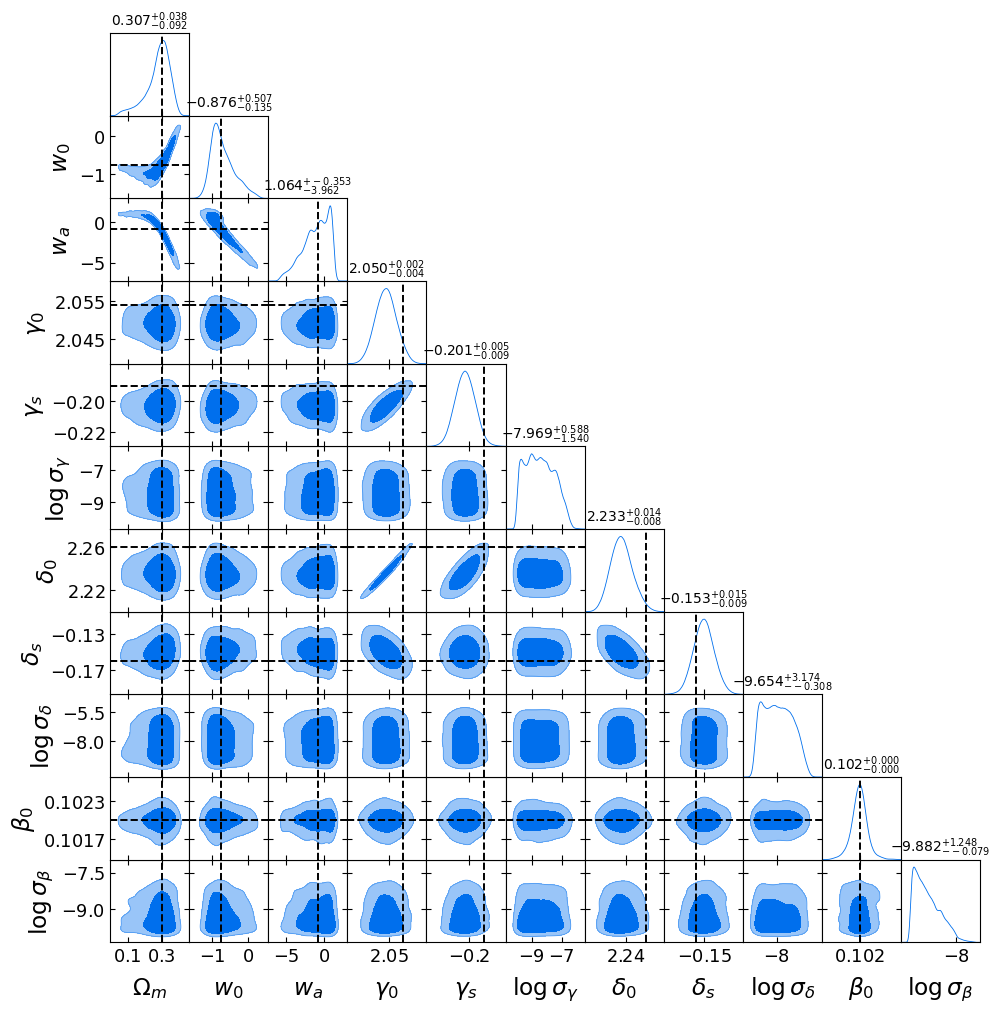

In [5]:
import os
import numpy as np
from getdist import MCSamples, plots as gdplots

BASE_OUT = "/home/geng/Codes/lensing_cosmo/jax01/output_lsst_sim"
full_labels = {
    "wcdm": "lsst146_wcdm_ann080",
    "w0wa": "lsst146_w0wa_ann080",
}

tail_keys = [
    "gamma0", "gamma_s", "log_sig_g",
    "delta0", "delta_s", "log_sig_d",
    "beta0", "log_sig_b",
]

ref_markers = {
    "wcdm": {
        "Om": 0.3, "w": -1.0,
        "gamma0": 2.054, "gamma_s": -0.19,
        "delta0": 2.26, "delta_s": -0.16,
        "beta0": 0.102,
    },
    "w0wa": {
        "Om": 0.3, "w0": -0.75, "wa": -0.86,
        "gamma0": 2.054, "gamma_s": -0.19,
        "delta0": 2.26, "delta_s": -0.16,
        "beta0": 0.102,
    },
}

def head_keys_for(model):
    if model == "wcdm":
        return ["Om", "w"]
    if model == "w0wa":
        return ["Om", "w0", "wa"]
    raise ValueError(f"unknown model: {model}")

def load_samples(npz_path, keys):
    data = np.load(npz_path)
    missing = [k for k in keys if k not in data.files]
    if missing:
        raise KeyError(f"npz missing keys: {missing}\navailable: {list(data.files)}")
    return np.vstack([data[k] for k in keys]).T

def peak_q16_q84(x, bins=200):
    hist, edges = np.histogram(x, bins=bins, density=True)
    i = int(np.argmax(hist))
    peak = 0.5 * (edges[i] + edges[i+1])
    q16, q84 = np.quantile(x, [0.16, 0.84])
    return float(peak), float(q16), float(q84)

name_map = {
    "Om": "Om", "w": "w", "w0": "w0", "wa": "wa",
    "gamma0": "gamma0", "gamma_s": "gamma_s", "log_sig_g": "log_sig_g",
    "delta0": "delta0", "delta_s": "delta_s", "log_sig_d": "log_sig_d",
    "beta0": "beta0", "log_sig_b": "log_sig_b",
}
label_map = {
    "Om": r"\Omega_m", "w": r"w", "w0": r"w_0", "wa": r"w_a",
    "gamma0": r"\gamma_0", "gamma_s": r"\gamma_s", "log_sig_g": r"\log\sigma_\gamma",
    "delta0": r"\delta_0", "delta_s": r"\delta_s", "log_sig_d": r"\log\sigma_\delta",
    "beta0": r"\beta_0", "log_sig_b": r"\log\sigma_\beta",
}

for model, label in full_labels.items():
    npz_path = os.path.join(BASE_OUT, f"posterior_minimal_chunks_{label}.npz")
    keys = head_keys_for(model) + tail_keys
    samples = load_samples(npz_path, keys)

    burn = int(0.4 * samples.shape[0])
    samples2 = samples[burn:]

    names = [name_map[k] for k in keys]
    labels = [label_map.get(k, k) for k in keys]

    mc = MCSamples(samples=samples2, names=names, labels=labels, label=label)
    g = gdplots.get_subplot_plotter(width_inch=10)
    g.settings.axes_labelsize = 22
    g.settings.axes_fontsize = 18
    g.triangle_plot(
        [mc],
        filled=True,
        title_limit=0,
        markers=ref_markers[model],
        marker_args={"lw": 1.4, "ls": "--", "color": "k"},
    )

    for i, k in enumerate(keys):
        peak, q16, q84 = peak_q16_q84(samples2[:, i])
        dminus = peak - q16
        dplus = q84 - peak
        ax = g.subplots[i, i]
        ax.set_title(rf"${peak:.3f}_{{-{dminus:.3f}}}^{{+{dplus:.3f}}}$", fontsize=10)

    out_path = os.path.join(BASE_OUT, f"getdist_peak_{label}.png")
    g.export(out_path)
    print("Saved:", out_path)


Removed no burn in
Saved: /home/geng/Codes/lensing_cosmo/jax01/output_lsst_sim/getdist_peak_lsst146_wcdm_ann1.png
Removed no burn in
Saved: /home/geng/Codes/lensing_cosmo/jax01/output_lsst_sim/getdist_peak_lsst146_w0wa_ann1.png


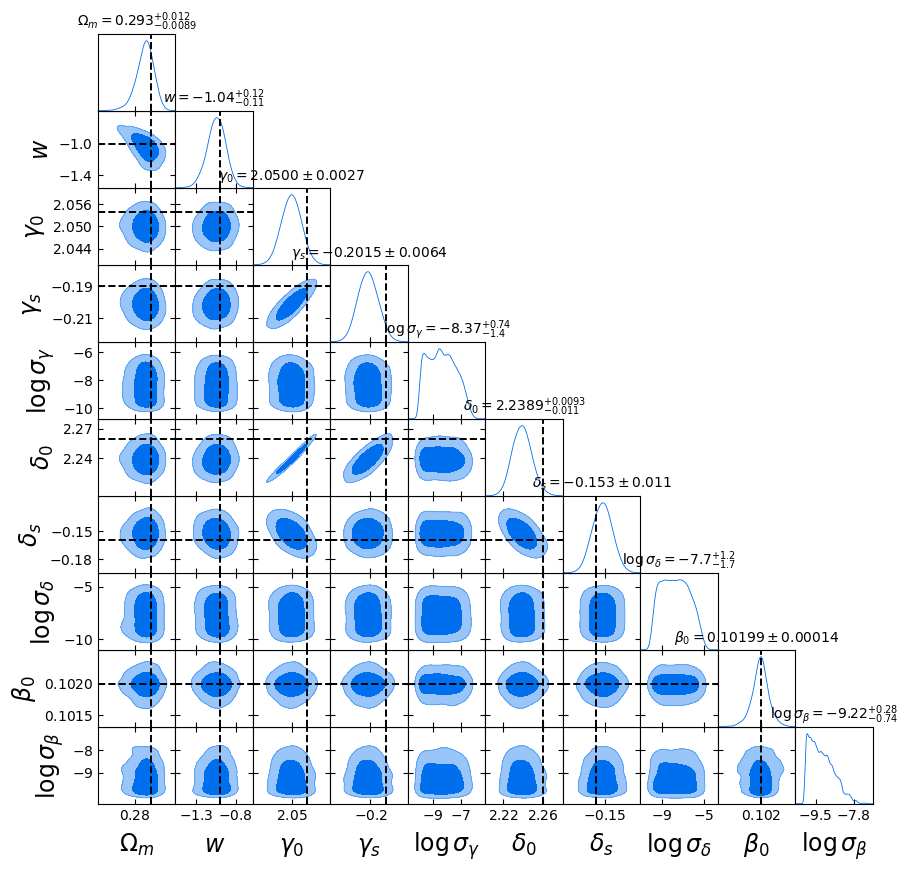

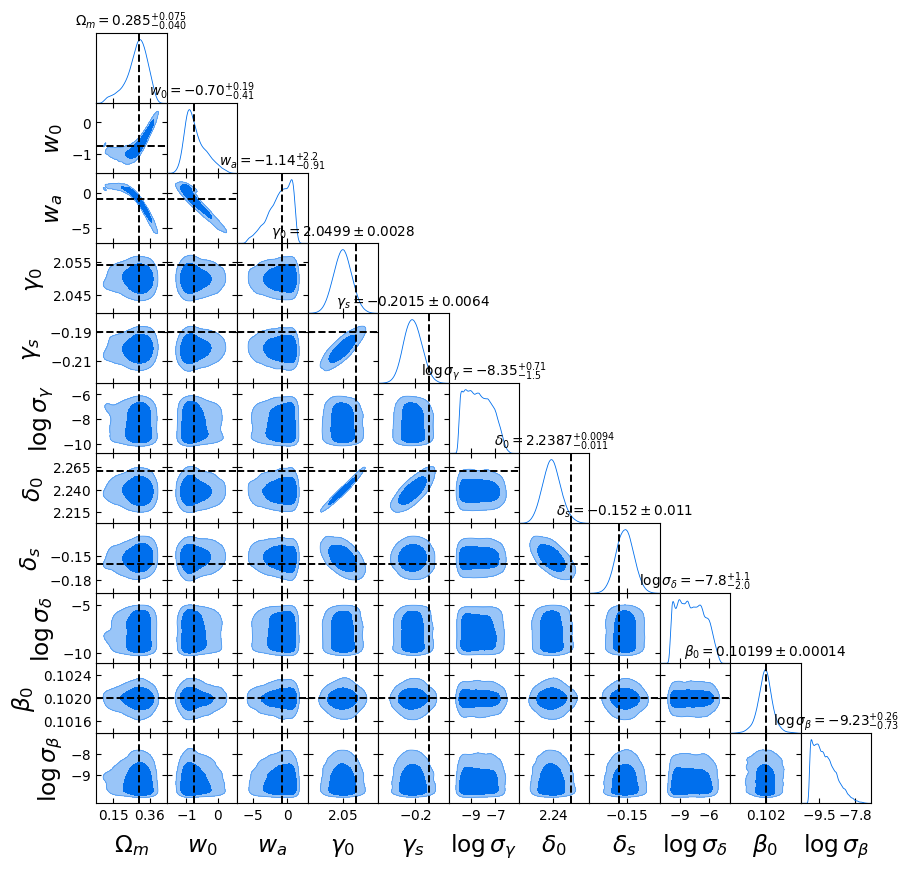

In [1]:
import os
import numpy as np
from getdist import MCSamples, plots as gdplots

BASE_OUT = "/home/geng/Codes/lensing_cosmo/jax01/output_lsst_sim"
full_labels = {
    "wcdm": "lsst146_wcdm_ann1",
    "w0wa": "lsst146_w0wa_ann1",
}

tail_keys = [
    "gamma0", "gamma_s", "log_sig_g",
    "delta0", "delta_s", "log_sig_d",
    "beta0", "log_sig_b",
]

ref_markers = {
    "wcdm": {
        "Om": 0.3, "w": -1.0,
        "gamma0": 2.054, "gamma_s": -0.19,
        "delta0": 2.26, "delta_s": -0.16,
        "beta0": 0.102,
    },
    "w0wa": {
        "Om": 0.3, "w0": -0.75, "wa": -0.86,
        "gamma0": 2.054, "gamma_s": -0.19,
        "delta0": 2.26, "delta_s": -0.16,
        "beta0": 0.102,
    },
}

def head_keys_for(model):
    if model == "wcdm":
        return ["Om", "w"]
    if model == "w0wa":
        return ["Om", "w0", "wa"]
    raise ValueError(f"unknown model: {model}")

def load_samples(npz_path, keys):
    data = np.load(npz_path)
    missing = [k for k in keys if k not in data.files]
    if missing:
        raise KeyError(f"npz missing keys: {missing}\navailable: {list(data.files)}")
    return np.vstack([data[k] for k in keys]).T

def peak_q16_q84(x, bins=200):
    hist, edges = np.histogram(x, bins=bins, density=True)
    i = int(np.argmax(hist))
    peak = 0.5 * (edges[i] + edges[i+1])
    q16, q84 = np.quantile(x, [0.16, 0.84])
    return float(peak), float(q16), float(q84)

name_map = {
    "Om": "Om", "w": "w", "w0": "w0", "wa": "wa",
    "gamma0": "gamma0", "gamma_s": "gamma_s", "log_sig_g": "log_sig_g",
    "delta0": "delta0", "delta_s": "delta_s", "log_sig_d": "log_sig_d",
    "beta0": "beta0", "log_sig_b": "log_sig_b",
}
label_map = {
    "Om": r"\Omega_m", "w": r"w", "w0": r"w_0", "wa": r"w_a",
    "gamma0": r"\gamma_0", "gamma_s": r"\gamma_s", "log_sig_g": r"\log\sigma_\gamma",
    "delta0": r"\delta_0", "delta_s": r"\delta_s", "log_sig_d": r"\log\sigma_\delta",
    "beta0": r"\beta_0", "log_sig_b": r"\log\sigma_\beta",
}

for model, label in full_labels.items():
    npz_path = os.path.join(BASE_OUT, f"posterior_minimal_chunks_{label}.npz")
    keys = head_keys_for(model) + tail_keys
    samples = load_samples(npz_path, keys)

    burn = int(0.4 * samples.shape[0])
    samples2 = samples[burn:]

    names = [name_map[k] for k in keys]
    labels = [label_map.get(k, k) for k in keys]

    mc = MCSamples(samples=samples2, names=names, labels=labels, label=label)
    g = gdplots.get_subplot_plotter(width_inch=10)
    g.settings.axes_labelsize = 22
    g.settings.axes_fontsize = 15
    g.triangle_plot(
        [mc],
        filled=True,
        title_limit=1,
        markers=ref_markers[model],
        marker_args={"lw": 1.4, "ls": "--", "color": "k"},
    )

    # for i, k in enumerate(keys):
    #     peak, q16, q84 = peak_q16_q84(samples2[:, i])
    #     dminus = peak - q16
    #     dplus = q84 - peak
    #     ax = g.subplots[i, i]
    #     ax.set_title(rf"${peak:.3f}_{{-{dminus:.3f}}}^{{+{dplus:.3f}}}$", fontsize=10)

    out_path = os.path.join(BASE_OUT, f"getdist_peak_{label}.png")
    g.export(out_path)
    print("Saved:", out_path)
